In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib 
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

from utils import set_seed
set_seed(42)



 Random seed зафиксирован: 42


# Загрузка данных и создание вектора Target

In [2]:
df_features = pd.read_csv('data/features.csv')
feature_cols = [col for col in df_features.columns if col not in ['timestamp', 'consumption']]

HORIZON = 24

def create_multistep_targets(series, horizon=24):
    targets = []
    for i in range(len(series) - horizon):
        window = series.iloc[i+1 : i+1+horizon].values
        targets.append(window)
    return np.array(targets)

y_multi = create_multistep_targets(df_features['consumption'], horizon=HORIZON)
X_multi = df_features[feature_cols].iloc[:-HORIZON].copy()
dates = pd.to_datetime(df_features['timestamp']).iloc[:-HORIZON].values

assert len(X_multi) == len(y_multi), "ERROR - Ошибка размерности"

split_idx = int(len(X_multi) * 0.8)

X_train, X_test = X_multi.iloc[:split_idx], X_multi.iloc[split_idx:]
y_train, y_test = y_multi[:split_idx], y_multi[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print(f"Размер X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размер X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Размер X_train: (6853, 57), y_train: (6853, 24)
Размер X_test:  (1714, 57),  y_test:  (1714, 24)


# Функция для вывода метрик и отрисовки

In [3]:

def evaluate_and_plot(model, X_train, y_train, X_test, y_test, dates_test, model_name):
    print(f"Оценка модели: {model_name}")
    
    # 1. Прогнозы 
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 2. Расчет метрик
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"TRAIN  MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R2: {r2_train:.4f}")
    print(f"TEST   MAE: {mae_test:.2f}  | RMSE: {rmse_test:.2f}  | R2: {r2_test:.4f}")
    
    # 3. Визуализация первой недели теста (168 часов) для горизонта +1 час
    n_vis = 168
    step_idx = 0 # Смотрим только на прогноз следующего часа
    
    test_vis = y_test[:n_vis, step_idx] 
    pred_vis = y_pred_test[:n_vis, step_idx]
    dates_vis = dates_test[:n_vis]
    
    plt.figure(figsize=(16, 6))
    plt.plot(dates_vis, test_vis, label='Факт', color='steelblue', linewidth=2)
    plt.plot(dates_vis, pred_vis, label=f'Прогноз ({model_name})', color='darkorange', linewidth=2, linestyle='--')
    
    plt.title(f'{model_name}: Сравнение факта и прогноза на горизонт +1 час (Тестовая выборка)', fontsize=14)
    plt.ylabel('Потребление (Вт)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()


# Обучение XGBoost

Оценка модели: XGBoost
TRAIN  MAE: 42818.09 | RMSE: 54437.55 | R2: 0.9965
TEST   MAE: 112094.78  | RMSE: 156096.67  | R2: 0.9747
 Веса XGBoost сохранены в model_weights/xgb_base.joblib


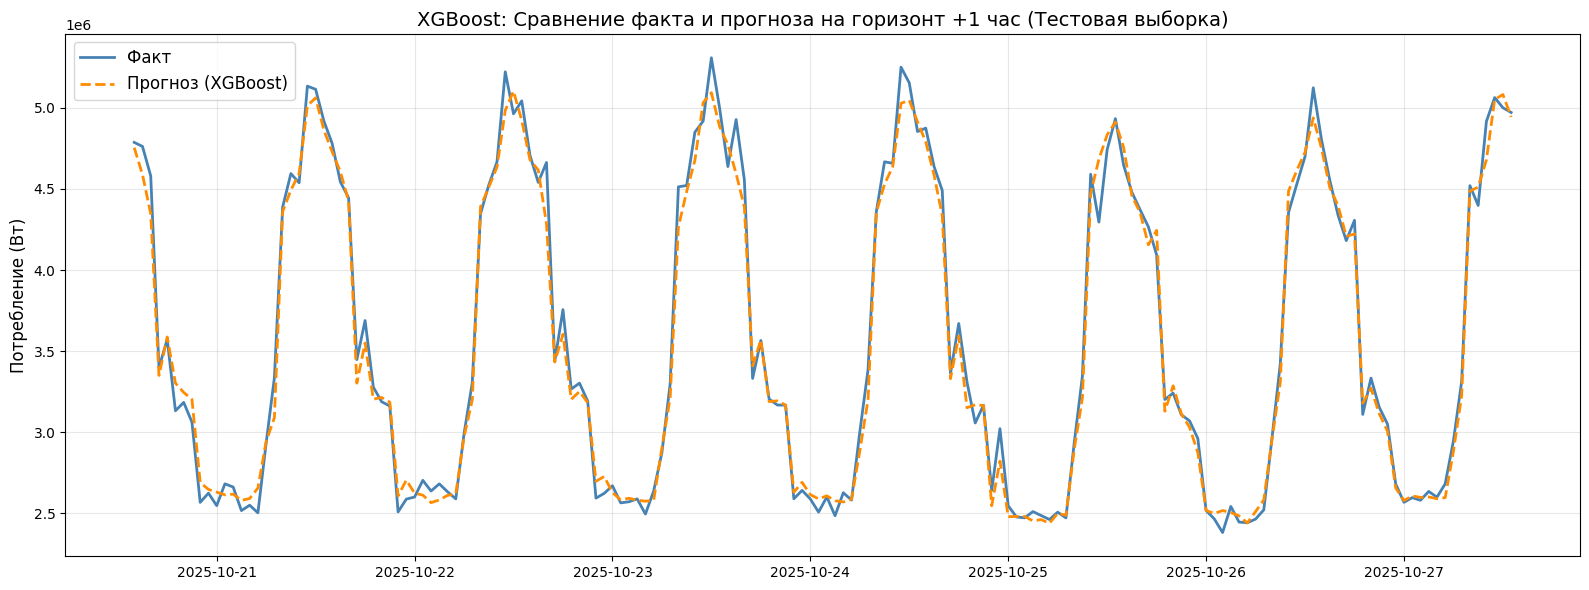

In [4]:


model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method='hist' 
)

model_xgb.fit(X_train, y_train, verbose=False)

evaluate_and_plot(model_xgb, X_train, y_train, X_test, y_test, dates_test, "XGBoost")

joblib.dump(model_xgb, 'model_weights/xgb_base.joblib')
print(" Веса XGBoost сохранены в model_weights/xgb_base.joblib")

# Обучение CatBoost

Got unsafe target value = 2.39981e+06 at object #0 of dataset learn
Got unsafe target value = 2.40341e+06 at object #0 of dataset learn
Got unsafe target value = 2.43951e+06 at object #0 of dataset learn
Got unsafe target value = 2.45995e+06 at object #0 of dataset learn
Got unsafe target value = 2.4568e+06 at object #0 of dataset learn
Got unsafe target value = 2.4837e+06 at object #0 of dataset learn
Got unsafe target value = 2.46984e+06 at object #0 of dataset learn
Got unsafe target value = 3.06912e+06 at object #0 of dataset learn
Got unsafe target value = 3.42343e+06 at object #0 of dataset learn
Got unsafe target value = 4.89991e+06 at object #0 of dataset learn
Got unsafe target value = 4.8422e+06 at object #0 of dataset learn
Got unsafe target value = 4.82388e+06 at object #0 of dataset learn
Got unsafe target value = 5.04713e+06 at object #0 of dataset learn
Got unsafe target value = 5.0708e+06 at object #0 of dataset learn
Got unsafe target value = 4.60721e+06 at object #0 o

Оценка модели: CatBoost
TRAIN  MAE: 90680.44 | RMSE: 127524.85 | R2: 0.9810
TEST   MAE: 127997.39  | RMSE: 174462.77  | R2: 0.9684
 Веса CatBoost сохранены в model_weights/catboost_base.joblib


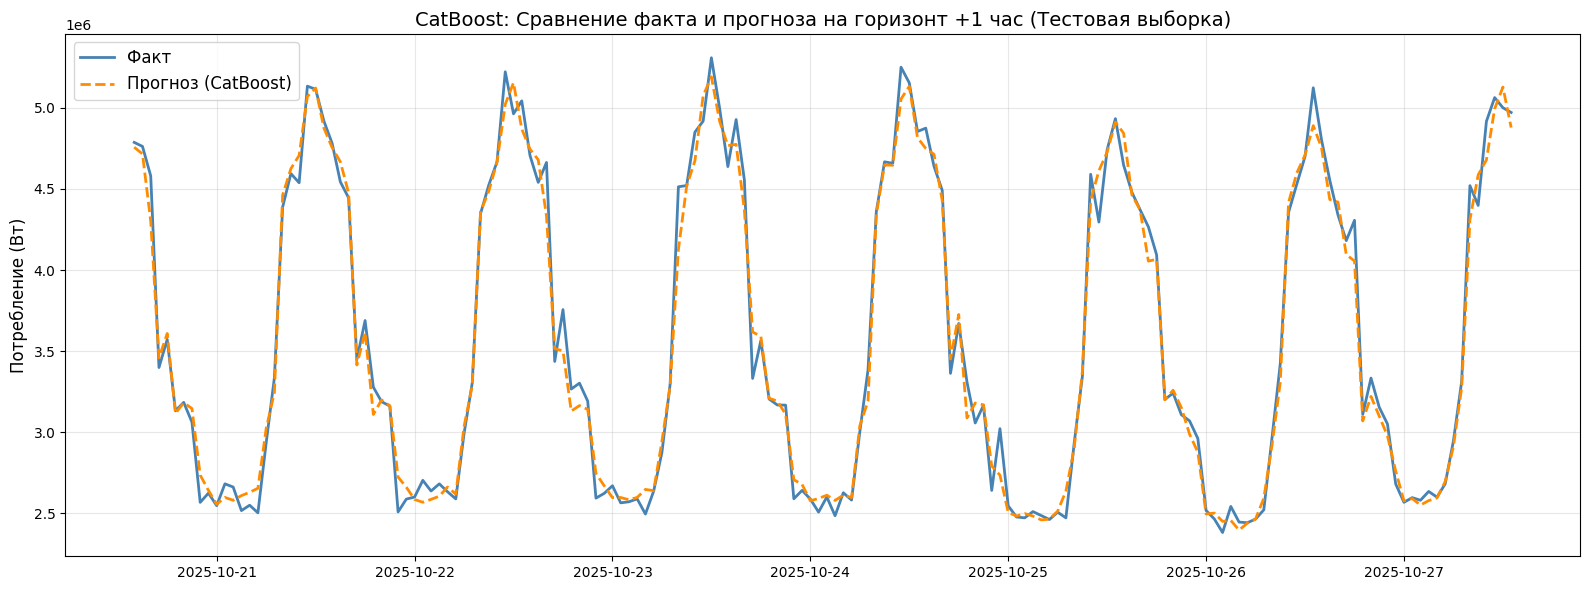

In [5]:


model_cat = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=3,
    l2_leaf_reg=3,
    loss_function='MultiRMSE', #  для предсказания вектора из 24 значений
    eval_metric='MultiRMSE',
    random_seed=42,
    verbose=0, 
    early_stopping_rounds=100
)

model_cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

evaluate_and_plot(model_cat, X_train, y_train, X_test, y_test, dates_test, "CatBoost")


joblib.dump(model_cat, 'model_weights/catboost_base.joblib')
print(" Веса CatBoost сохранены в model_weights/catboost_base.joblib")

# Обучение Random Forest

Оценка модели: Random Forest
TRAIN  MAE: 56438.34 | RMSE: 75354.57 | R2: 0.9934
TEST   MAE: 132914.72  | RMSE: 173567.37  | R2: 0.9687
 Веса Random Forest сохранены в model_weights/rf_base.joblib


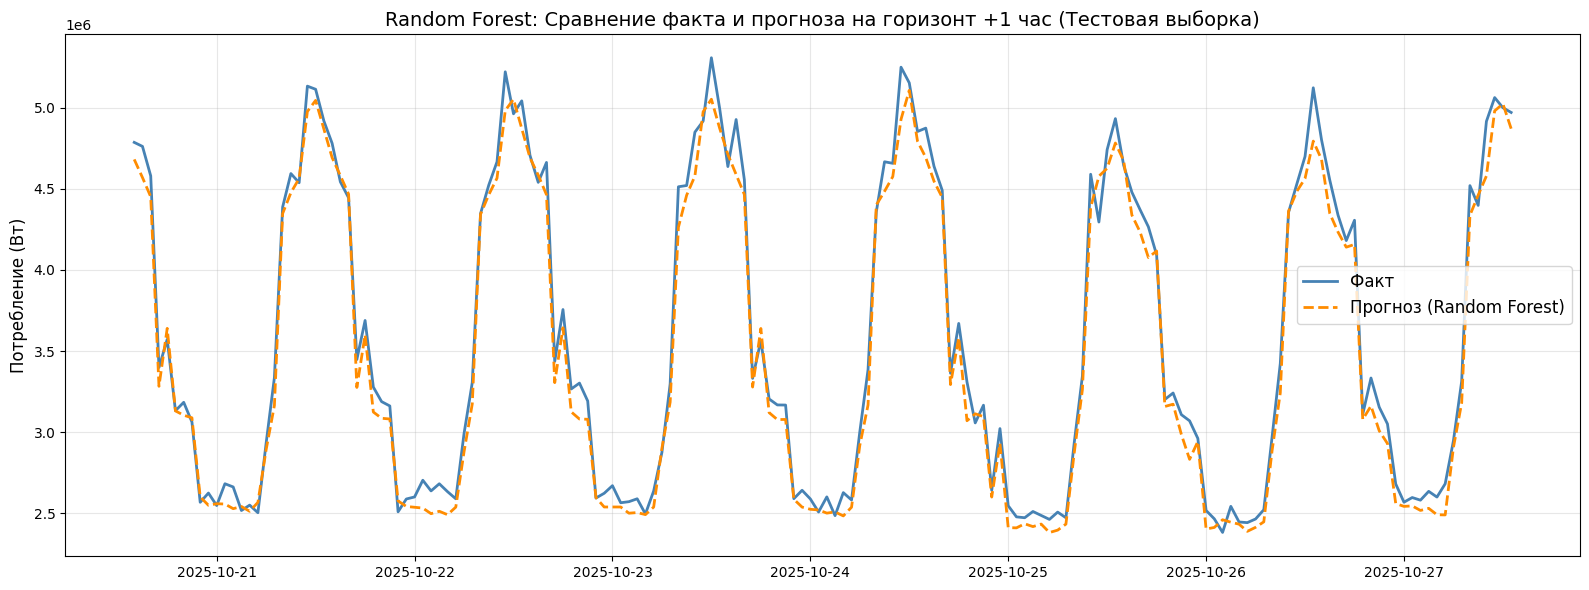

In [6]:


model_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

evaluate_and_plot(model_rf, X_train, y_train, X_test, y_test, dates_test, "Random Forest")


joblib.dump(model_rf, 'model_weights/rf_base.joblib')
print(" Веса Random Forest сохранены в model_weights/rf_base.joblib")

# Итоговое сравнение базовых моделей (Метрики + Графики)

       Модель   MAE (Вт)  RMSE (Вт)  R2 Score
      XGBoost 112094.779 156096.666     0.975
     CatBoost 127997.386 174462.766     0.968
Random Forest 132914.716 173567.372     0.969


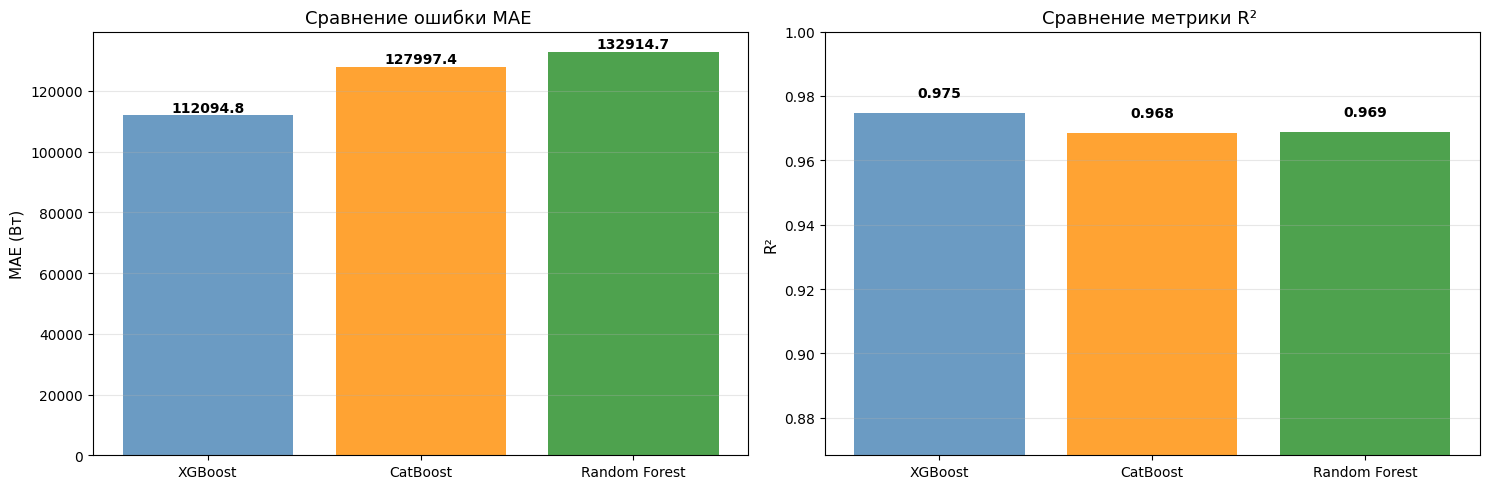

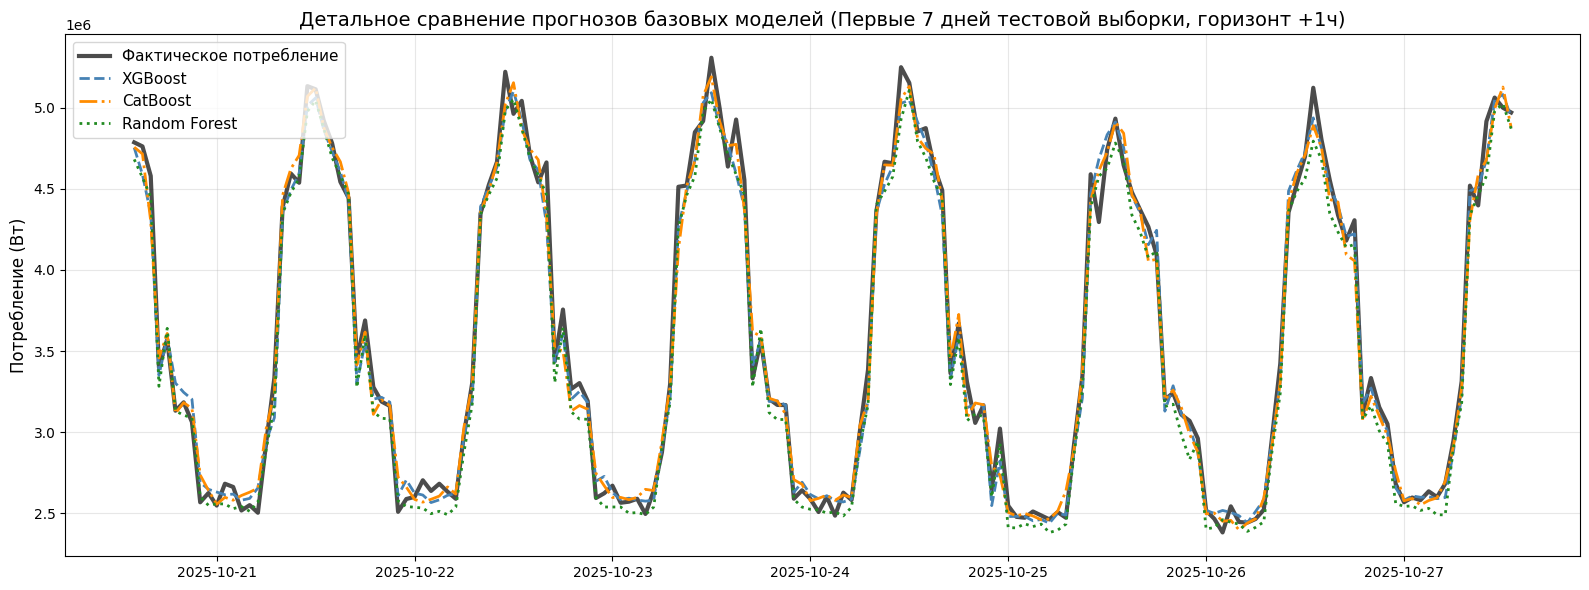

In [7]:


y_pred_xgb = model_xgb.predict(X_test)
y_pred_cat = model_cat.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

models_info = [
    ("XGBoost", y_pred_xgb),
    ("CatBoost", y_pred_cat),
    ("Random Forest", y_pred_rf)
]

metrics_list = []
for name, preds in models_info:
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics_list.append({"Модель": name, "MAE (Вт)": mae, "RMSE (Вт)": rmse, "R2 Score": r2})

df_metrics = pd.DataFrame(metrics_list)

print(df_metrics.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_colors = ['steelblue', 'darkorange', 'forestgreen']

axes[0].bar(df_metrics["Модель"], df_metrics["MAE (Вт)"], color=model_colors, alpha=0.8)
axes[0].set_title('Сравнение ошибки MAE ', fontsize=13)
axes[0].set_ylabel('MAE (Вт)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(df_metrics["Модель"], df_metrics["R2 Score"], color=model_colors, alpha=0.8)
axes[1].set_title('Сравнение метрики R² ', fontsize=13)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(bottom=max(0, df_metrics["R2 Score"].min() - 0.1), top=1.0)

for i, v in enumerate(df_metrics["MAE (Вт)"]):
    axes[0].text(i, v + (v*0.01), f"{v:.1f}", ha='center', fontweight='bold')
for i, v in enumerate(df_metrics["R2 Score"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/05_base_models_metrics.png', dpi=150, bbox_inches='tight')

n_vis = 168
step_idx = 0 

plt.figure(figsize=(16, 6))
plt.plot(dates_test[:n_vis], y_test[:n_vis, step_idx], label='Фактическое потребление', color='black', linewidth=3, alpha=0.7)

plt.plot(dates_test[:n_vis], y_pred_xgb[:n_vis, step_idx], label='XGBoost', color='steelblue', linewidth=2, linestyle='--')
plt.plot(dates_test[:n_vis], y_pred_cat[:n_vis, step_idx], label='CatBoost', color='darkorange', linewidth=2, linestyle='-.')
plt.plot(dates_test[:n_vis], y_pred_rf[:n_vis, step_idx], label='Random Forest', color='forestgreen', linewidth=2, linestyle=':')

plt.title('Детальное сравнение прогнозов базовых моделей (Первые 7 дней тестовой выборки, горизонт +1ч)', fontsize=14)
plt.ylabel('Потребление (Вт)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/06_base_models_timeseries.png', dpi=150, bbox_inches='tight')

